In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import os
import requests
from zipfile import ZipFile
from PIL import Image
import matplotlib.patches as patches
from torchvision.transforms import ToTensor, ColorJitter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q '/content/drive/MyDrive/VisDrone2019-DET-train.zip' -d /content/visdrone
!unzip -q '/content/drive/MyDrive/VisDrone2019-DET-val.zip' -d /content/visdroneval

In [ ]:
class Yolo(nn.Module):
    def __init__(self, in_channels=3, S=7, B=1, C=10):
        super(Yolo, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.architecture = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 512, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(1024, 512, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 512, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(4096, S * S * (C + B * 5))
        )

    def forward(self, x):
        x = self.architecture(x)
        x = x.view(-1, self.S, self.S, self.C + self.B * 5)
        x[..., :5] = torch.sigmoid(x[..., :5])
        x[..., 5:] = torch.nn.functional.softmax(x[..., 5:], dim=-1)
        return x

In [ ]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=1, C=10, lambda_coord=5, lambda_noobj=0.5):
        super(YoloLoss, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, predictions, targets):
        #predictions = predictions.view(-1, self.S, self.S, self.C + self.B * 5)

        box_loss = self.compute_box_loss(predictions, targets)
        object_loss = self.compute_object_loss(predictions, targets)
        no_object_loss = self.compute_no_object_loss(predictions, targets)
        class_loss = self.compute_class_loss(predictions, targets)

        total_loss = (self.lambda_coord * box_loss +
                      object_loss +
                      self.lambda_noobj * no_object_loss + class_loss)
        batch_size = predictions.size(0)
        return total_loss/(batch_size)

    def compute_box_loss(self, predictions, targets):
        mse_loss = nn.MSELoss(reduction='sum')

        object_mask = targets[..., 4] == 1 #when there is an object
        predictions = predictions[object_mask]
        targets = targets[object_mask]

        coord_loss = mse_loss(predictions[..., :2], targets[..., :2])

        dimensions_loss = mse_loss(torch.sqrt(predictions[..., 2:4]), torch.sqrt(targets[..., 2:4]))

        box_loss = coord_loss + dimensions_loss

        return box_loss

    def compute_object_loss(self, predictions, targets):
        mse_loss = nn.MSELoss(reduction='sum')

        object_mask = targets[..., 4] == 1 #when there is an object
        object_predictions = predictions[object_mask]
        object_targets = targets[object_mask]

        object_loss = mse_loss(object_predictions[..., 4], object_targets[..., 4])

        return object_loss

    def compute_no_object_loss(self, predictions, targets):
        mse_loss = nn.MSELoss(reduction='sum')

        no_object_mask = targets[..., 4] == 0  #when there is no object
        no_object_predictions = predictions[no_object_mask]
        no_object_targets = targets[no_object_mask]

        no_object_loss = mse_loss(no_object_predictions[..., 4], no_object_targets[..., 4])

        return no_object_loss

    def compute_class_loss(self, predictions, targets):
        mse_loss = nn.MSELoss(reduction='sum')

        object_mask = targets[..., 4] == 1  #when there is an object
        class_predictions = predictions[object_mask]
        class_targets = targets[object_mask]

        class_loss = mse_loss(class_predictions[..., 5:], class_targets[..., 5:])

        return class_loss

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image, ImageDraw

class VisDroneDataset(Dataset):
    def __init__(self, images_path, annotations_path, transforms=None, S=7):
        self.images_path = images_path
        self.annotations_path = annotations_path
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(images_path)))
        self.labels = list(sorted(os.listdir(annotations_path)))
        self.S = S

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_path, self.imgs[idx])
        label_path = os.path.join(self.annotations_path, self.labels[idx])

        img = Image.open(img_path).convert("RGB")
        original_size = img.size
        img_resized = img.resize((448, 448))  # Resize the image to 448x448

        # Draw all bounding boxes
        full_box_img = img_resized.copy()
        self.draw_boxes(full_box_img, label_path, original_size, (448, 448), all_boxes=True)

        # Draw one bounding box per cell
        one_box_img = img_resized.copy()
        self.draw_boxes(one_box_img, label_path, original_size, (448, 448), all_boxes=False)

        if self.transforms:
            full_box_img = self.transforms(full_box_img)
            one_box_img = self.transforms(one_box_img)

        return full_box_img, one_box_img

    def __len__(self):
        return len(self.imgs)

    def draw_boxes(self, img, annotation_path, original_size, new_size, all_boxes=True):
        original_width, original_height = original_size
        new_width, new_height = new_size
        S = self.S
        grid_size = new_width / S

        draw = ImageDraw.Draw(img)
        cell_occupied = set()

        with open(annotation_path, 'r') as file:
            for line in file.readlines():
                bbox_left, bbox_top, bbox_width, bbox_height, _, object_category = map(int, line.strip().split(',')[:6])
                if object_category == 0 or bbox_width <= 0 or bbox_height <= 0:
                    continue  # Ignore if the category is ignored regions or bbox dimensions are non-positive

                # Scale bounding boxes to the new image size
                new_bbox_left = bbox_left * new_width / original_width
                new_bbox_top = bbox_top * new_height / original_height
                new_bbox_width = bbox_width * new_width / original_width
                new_bbox_height = bbox_height * new_height / original_height

                # Calculate grid cell position
                grid_x = int(new_bbox_left // grid_size)
                grid_y = int(new_bbox_top // grid_size)

                if not all_boxes:
                    # If we're only drawing one box per cell, skip if the cell is already occupied
                    if (grid_x, grid_y) in cell_occupied:
                        continue
                    cell_occupied.add((grid_x, grid_y))

                # Draw the bounding box
                draw.rectangle([new_bbox_left, new_bbox_top,
                                new_bbox_left + new_bbox_width, new_bbox_top + new_bbox_height],
                               outline="red", width=2)

        del draw

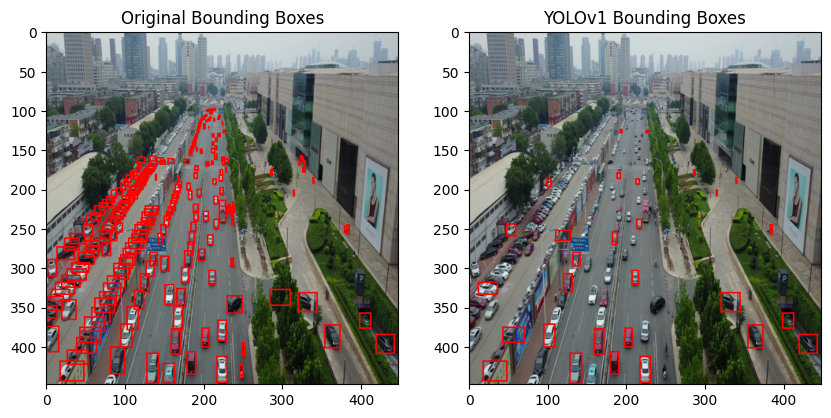

In [ ]:
# Define mean and std for normalization

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Define the full paths for images and annotations
images_path = '/content/visdrone/VisDrone2019-DET-train/images'
annotations_path = '/content/visdrone/VisDrone2019-DET-train/annotations'
dataset = VisDroneDataset(images_path, annotations_path, S=7)

for i in range(190,len(dataset)):
    full_box_img, one_box_img = dataset[i]

    # Convert to a format suitable for display with matplotlib if needed
    full_box_img = full_box_img.convert("RGB")
    one_box_img = one_box_img.convert("RGB")

    # Display images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(full_box_img)
    plt.title("Original Bounding Boxes")

    plt.subplot(1, 2, 2)
    plt.imshow(one_box_img)
    plt.title("YOLOv1 Bounding Boxes")

    plt.show()
    break


tensor(4)
tensor(4)
tensor(4)
tensor(4)
tensor(4)
tensor(4)
tensor(4)
tensor(2)
tensor(4)
tensor(4)


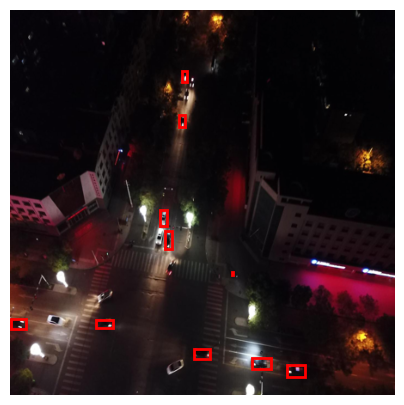

In [ ]:
  import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
def denormalize(image, mean, std):
    """
    Denormalize an image that was normalized using the given mean and std.
    """
    image = image * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return image
def show_images_with_boxes(images, targets, S=7, B=1, C=20, img_size=448):
    batch_size = len(images)
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))
    axs = [axs]
    targets = torch.stack(targets)
    for i in range(1,batch_size):
        img = denormalize(images[i], mean, std)  # Apply denormalization
        img = img.permute(1, 2, 0).numpy()  # Convert from [C, H, W] to [H, W, C]
        axs[0].imshow(img)

        # For each cell in the grid
        for x in range(S):
            for y in range(S):
                if targets[i, x, y, 4] > 0.2:  # Check if there's an object
                    bbox = targets[i, x, y, :4]
                    # Convert bbox coordinates from relative to absolute
                    bbox[0] = (bbox[0] + x) / S
                    bbox[1] = (bbox[1] + y) / S
                    bbox[0] *= img_size
                    bbox[1] *= img_size
                    bbox[2] *= img_size
                    bbox[3] *= img_size
                    z = np.argmax(targets[i, x, y, 5:])
                    print(z)
                    # Create a Rectangle patch
                    rect = patches.Rectangle((bbox[0] - bbox[2] / 2, bbox[1] - bbox[3] / 2), bbox[2], bbox[3],
                                             linewidth=2, edgecolor='r', facecolor='none')
                    axs[0].add_patch(rect)

        axs[0].axis('off')
        break
    plt.show()

# Fetch a batch of data
inputs, labels = next(iter(train_loader))
show_images_with_boxes(inputs, labels)


In [ ]:
import torch.optim as optim

# Initialize the model, loss function, and optimizer
model = Yolo(in_channels=3, S=7, B=1, C=10)
criterion = YoloLoss(S=7, B=1, C=10, lambda_coord=5, lambda_noobj=0.5)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = torch.stack(images).to(device)
        targets = torch.stack(targets).to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader)}")
